In [6]:
#imports
from keras.preprocessing.image import ImageDataGenerator

#paths definition
train_dir = "Datasets/training"
validation_dir="Datasets/validation"

In [7]:
#encode the images in float vector. 
train_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)
random = True
seed = 42
#A Python generator is an object that acts as an iterator: it’s an object you can use
#with the for … in operator. Generators are built using the yield operator
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(150, 150),
                                                    batch_size=20,
                                                    class_mode='binary', shuffle=random,
                                                    seed=seed)
validation_generator = test_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150),
    batch_size=20,
    class_mode='binary', shuffle=random,
    seed=seed)

for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    print(labels_batch[0:10])
    break
# i=0
# for item in validation_generator:
#     if i>10:
#         break
#     i+=1
#     print(item)


Found 1600 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)
[0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]


In [8]:
from keras import layers
from keras import models
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [9]:
from keras import optimizers
model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(lr=1e-4),
metrics=['acc'])

In [10]:
# Because the data is being generated endlessly, the Keras model
# needs to know how many samples to draw from the generator before declaring an
# epoch over. This is the role of the steps_per_epoch argument: after having drawn
# steps_per_epoch batches from the generator—that is, after having run for


history = model.fit_generator(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50)
model.save('cats_and_dogs_small_1.h5')


Epoch 1/30


  1/100 [..............................] - ETA: 12:32 - loss: 0.6956 - acc: 0.3500

  3/100 [..............................] - ETA: 4:07 - loss: 0.6723 - acc: 0.5167 

  5/100 [>.............................] - ETA: 2:26 - loss: 0.6863 - acc: 0.5100

  7/100 [=>............................] - ETA: 1:43 - loss: 0.6876 - acc: 0.5143

...

 96/100 [===========================>..] - ETA: 0s - loss: 0.0821 - acc: 0.9698

 97/100 [============================>.] - ETA: 0s - loss: 0.0814 - acc: 0.9701

 98/100 [============================>.] - ETA: 0s - loss: 0.0811 - acc: 0.9704

 99/100 [============================>.] - ETA: 0s - loss: 0.0805 - acc: 0.9707

100/100 [==============================] - 18s 175ms/step - loss: 0.0798 - acc: 0.9710 - val_loss: 0.1847 - val_acc: 0.9450


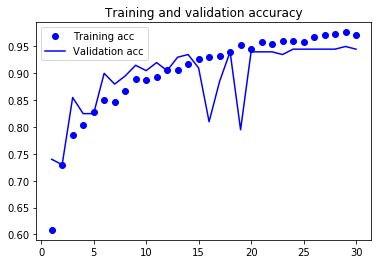

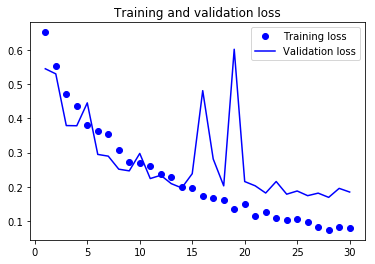

In [11]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()